# Forecast Using the PatchTST-FM Family


TimeCopilot ships a single `PatchTSTFM` class for IBM PatchTST time series foundation models. Pass the Hugging Face `repo_id` to select the checkpoint:

| Release | `repo_id` | License |
|---------|-----------|--------|
| **PatchTST-FM r1** (default) | `ibm-research/patchtst-fm-r1` | [CC-BY-NC-SA-4.0](https://huggingface.co/ibm-research/patchtst-fm-r1) (non-commercial) |
| **Granite PatchTST-FM r1** | `ibm-granite/granite-timeseries-patchtst-fm-r1` | [Apache-2.0](https://huggingface.co/ibm-granite/granite-timeseries-patchtst-fm-r1) |
| **Granite PatchTST-FM r2** | `ibm-granite/granite-timeseries-patchtst-fm-r2` | [Apache-2.0](https://huggingface.co/ibm-granite/granite-timeseries-patchtst-fm-r2) / [OpenMDW 1.0](https://openmdw.ai/license/1-0/) |

*Requirements*:

    - Python 3.11 – 3.13
    - CUDA recommended (CPU works but is slower)

**License:** Only `ibm-research/patchtst-fm-r1` is non-commercial. Granite r1 and r2 use permissive licenses suitable for commercial use.

PatchTST-FM supports flexible context lengths (default 8,192). We use `context_length=2048` here for a faster comparison. For probabilistic forecasts, pass `level` or `quantiles` (quantiles from 0.01 to 0.99).


## Import libraries


In [1]:
import sys

import pandas as pd

from timecopilot import TimeCopilotForecaster

if sys.version_info < (3, 11) or sys.version_info >= (3, 14):
    raise RuntimeError("PatchTST-FM requires Python >= 3.11 and < 3.14")


INFO:datasets:JAX version 0.7.1 available.
2026-09-23 14:04:14,687	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-09-23 14:04:15,038	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Load the dataset

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)


In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data


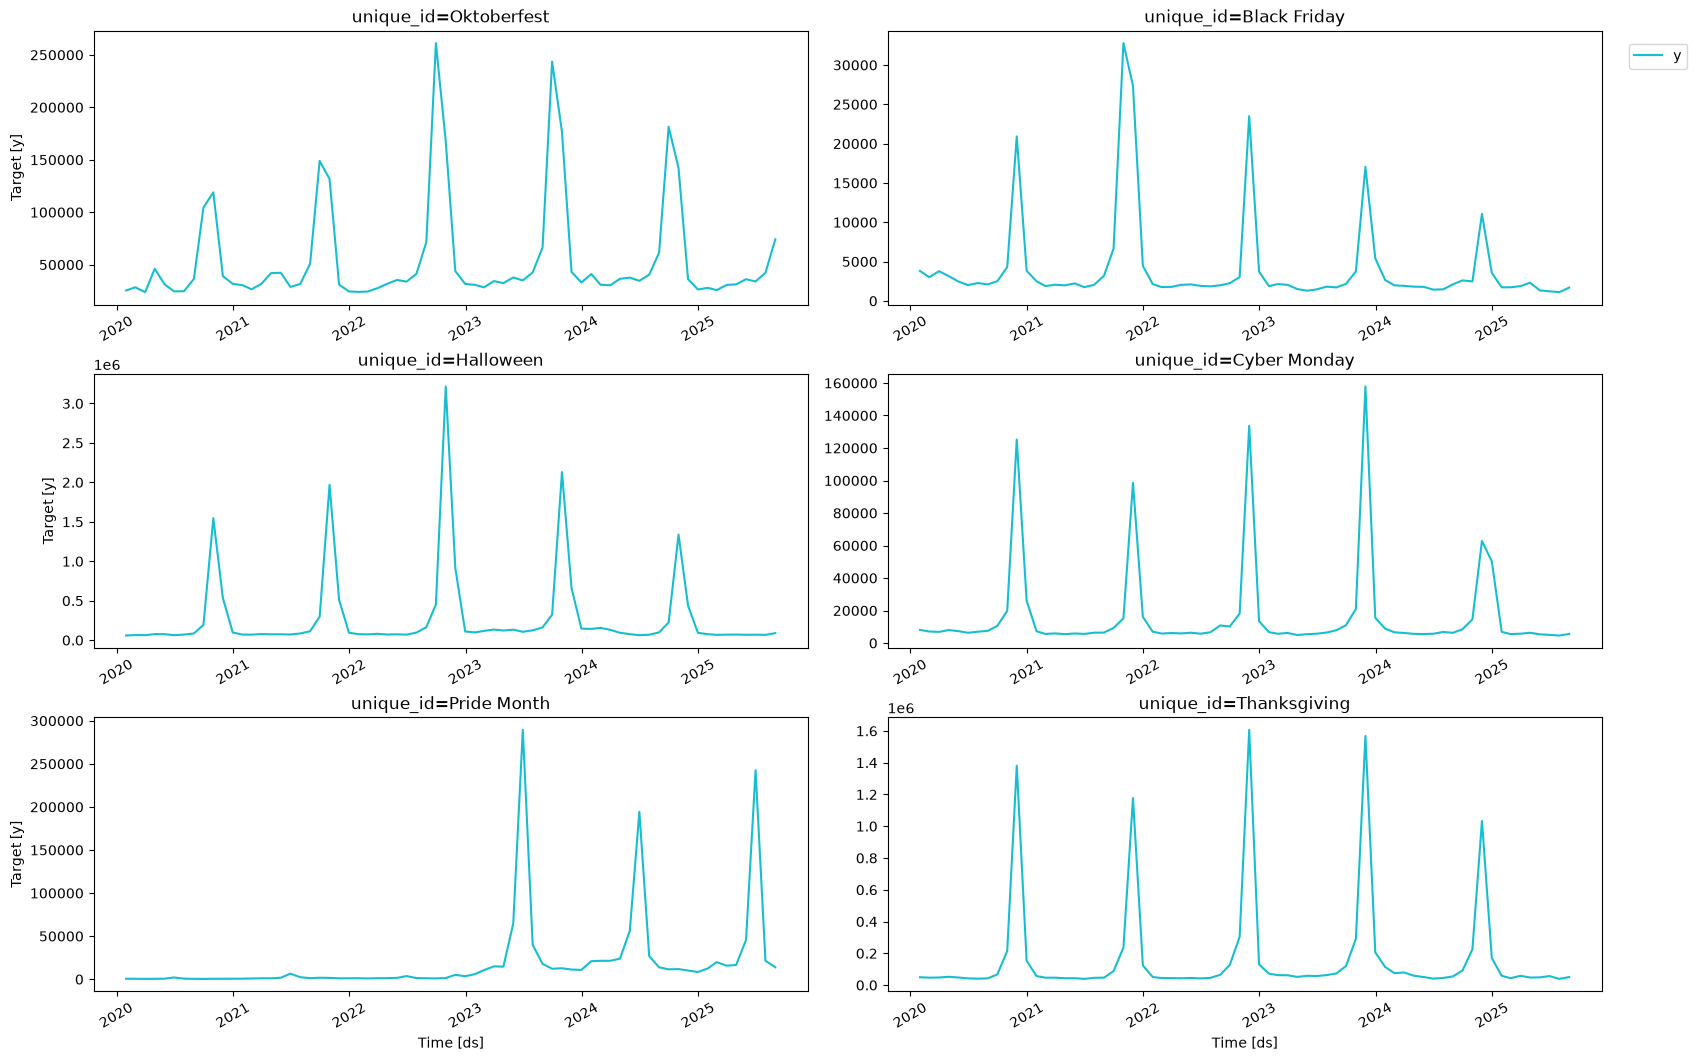

In [3]:
TimeCopilotForecaster.plot(df)


## Create a TimeCopilotForecaster

We compare IBM Research PatchTST-FM r1 with Granite PatchTST-FM r1 and r2. Each model gets a distinct `alias` so forecasts are easy to identify.


In [9]:
from timecopilot.models.foundation.patchtst_fm import PatchTSTFM

context_length = 2048
batch_size = 32

models = [
    PatchTSTFM(
        repo_id="ibm-research/patchtst-fm-r1",
        alias="PatchTST-FM-r1",
        context_length=context_length,
        batch_size=batch_size,
    ),
    PatchTSTFM(
        repo_id="ibm-granite/granite-timeseries-patchtst-fm-r1",
        alias="Granite-PatchTST-FM-r1",
        context_length=context_length,
        batch_size=batch_size,
    ),
    PatchTSTFM(
        repo_id="ibm-granite/granite-timeseries-patchtst-fm-r2",
        alias="Granite-PatchTST-FM-r2",
        context_length=context_length,
        batch_size=batch_size,
    ),
]

tcf = TimeCopilotForecaster(models=models)


## Cross-validate with prediction intervals

Optional parameters:
- `freq`: pandas frequency alias (inferred from `ds` if omitted)
- `h`: forecast horizon
- `level`: prediction interval levels (percent)

Pass `level` values that map to the model's 0.01-spaced quantiles (for example `80` → 0.1/0.9, `90` → 0.05/0.95).


In [5]:
# levels must map to 0.01-spaced model quantiles (e.g. 80→0.1/0.9, 90→0.05/0.95)
level = [80, 90]
h = 12
cv_df = tcf.cross_validation(df=df, h=h, level=level)
cv_df.head()


0it [00:00, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|██████████| 253/253 [00:00<00:00, 8405.02it/s]
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
100%|██████████| 1/1 [00:04<00:00,  4.87s/it]
1it [00:05,  5.45s/it]
100%|██████████| 1/1 [00:08<00:00,  8.09s/it]
1it [00:08,  8.53s/it]
0it [00:00, ?it/s]INFO:tsfm_public.models.patchtst_fm.modeling_patchtst_fm:Stacked blocks: (0):ConformerBlock-5 --> (1):ConformerBlock-5 --> (2):ConformerBlock-3 --> (3):ConformerBlock-3 --> (4):ConformerBlock-5 --> (5):ConformerBlock-5 --> (6):ConformerBlock-3 --> (7):ConformerBlock-3 --> (8):ConformerBlock-5 --> (9):ConformerBlock-5 --> (10):ConformerBlock-3 --> (11):ConformerBlock-3 --> (12):ConformerBlock-5 --> (13):ConformerBlock-5 --> (14):ConformerBlock-3 --> (15):ConformerBlock-3 --> (16):ConformerBlock-5 --> (17):ConformerBlock-5 --> (18):Conforme

,unique_id,ds,cutoff,y,PatchTST-FM-r1,PatchTST-FM-r1-lo-80,PatchTST-FM-r1-hi-80,PatchTST-FM-r1-lo-90,PatchTST-FM-r1-hi-90,Granite-PatchTST-FM-r1,Granite-PatchTST-FM-r1-lo-80,Granite-PatchTST-FM-r1-hi-80,Granite-PatchTST-FM-r1-lo-90,Granite-PatchTST-FM-r1-hi-90,Granite-PatchTST-FM-r2,Granite-PatchTST-FM-r2-lo-80,Granite-PatchTST-FM-r2-hi-80,Granite-PatchTST-FM-r2-lo-90,Granite-PatchTST-FM-r2-hi-90
0,Black Friday,2024-09-30,2024-08-31,2607,2097.164307,1727.202881,3229.980713,1311.553955,5043.822266,2018.981689,1770.181152,3816.510986,1501.957520,6320.073242,2367.684326,1840.466553,3370.302734,1673.035645,4834.735840
1,Black Friday,2024-10-31,2024-08-31,2470,2669.942383,1702.475342,6026.477051,1186.401123,9684.828125,2720.952148,1544.865967,10109.417969,1245.863525,16568.388672,3487.294922,2173.488525,14791.955078,1823.862305,21830.517578
2,Black Friday,2024-11-30,2024-08-31,11058,18250.660156,6540.333008,40904.207031,5253.758301,60771.214844,10829.052734,3100.690918,46892.488281,2217.646240,82391.531250,18171.929688,3252.875244,29226.037109,2109.260742,36364.984375
3,Black Friday,2024-12-31,2024-08-31,3548,4402.217773,1691.808838,13211.523438,1389.497559,19762.287109,4263.519531,1263.565918,20130.382812,965.645996,31476.011719,4231.202637,2607.727783,15159.037109,2197.693115,23046.003906
4,Black Friday,2025-01-31,2024-08-31,1724,2146.665039,1472.426514,5104.978516,1193.615723,8313.676758,2245.810791,1725.767334,7961.554688,1563.152588,12675.156250,2244.092529,1669.365234,3507.727539,1474.717285,5319.474121


## Plot cross-validation forecasts


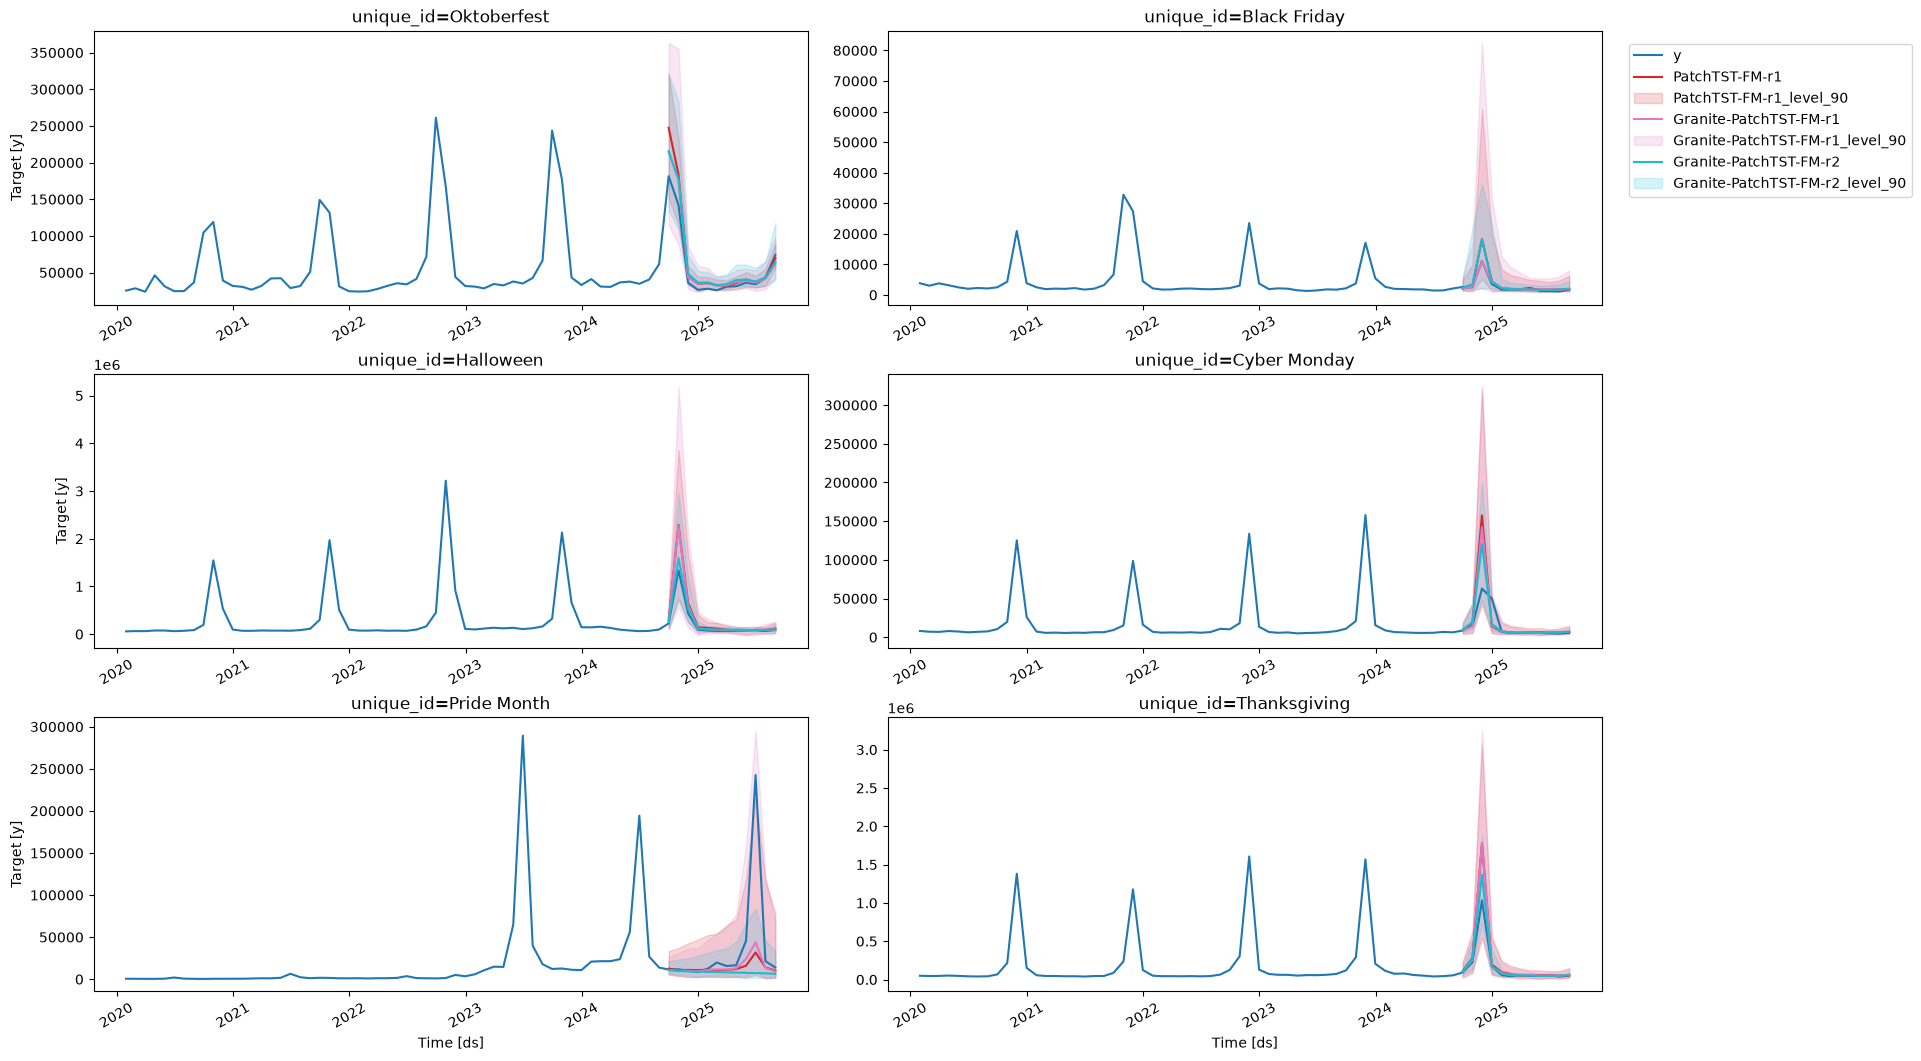

In [6]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[90])


## Plot forecast comparison

One panel per event series. Each panel overlays all PatchTST-FM checkpoints; **Granite PatchTST-FM r2** is highlighted with its 80% prediction interval. Saved to `patchtst-fm-family-forecast.png`.


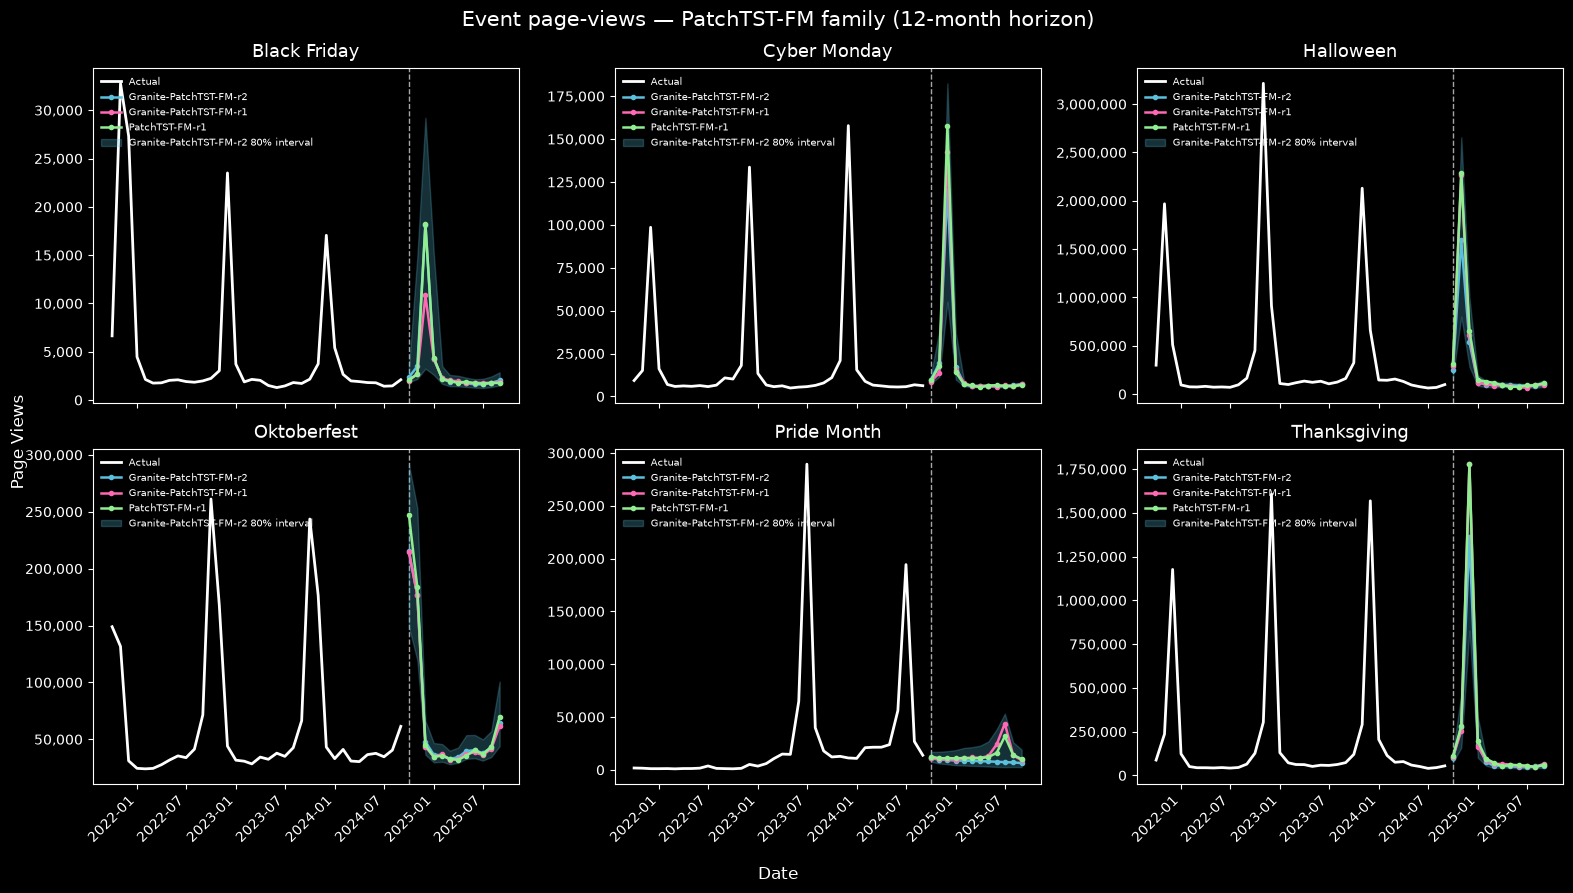

In [10]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("dark_background")

series_ids = sorted(df["unique_id"].unique())
highlight = "Granite-PatchTST-FM-r2"
forecast_models = [
    "Granite-PatchTST-FM-r2",
    "Granite-PatchTST-FM-r1",
    "PatchTST-FM-r1",
]
model_colors = {
    "Granite-PatchTST-FM-r2": "#5bc0de",
    "Granite-PatchTST-FM-r1": "#ff69b4",
    "PatchTST-FM-r1": "#90ee90",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.ravel()

for ax, series_id in zip(axes, series_ids, strict=True):
    fcst_all = cv_df.query("unique_id == @series_id").sort_values("ds")
    cutoff = fcst_all["cutoff"].iloc[0]
    forecast_start = fcst_all["ds"].min()
    history_start = forecast_start - pd.DateOffset(months=3 * h)

    series_df = df.query("unique_id == @series_id and ds >= @history_start").sort_values("ds")
    fcst_df = (
        cv_df.query("unique_id == @series_id and ds >= @history_start")
        .sort_values("ds")
        .copy()
    )
    insample = series_df.query("ds <= @cutoff")
    forecast = fcst_df.query("ds >= @forecast_start")

    ax.plot(
        insample["ds"],
        insample["y"],
        color="white",
        linewidth=2.0,
        label="Actual",
        zorder=5,
    )
    for model in forecast_models:
        ax.plot(
            forecast["ds"],
            forecast[model],
            color=model_colors[model],
            linewidth=1.8,
            marker="o",
            markersize=3,
            label=model,
            zorder=4,
        )
    ax.fill_between(
        forecast["ds"],
        forecast[f"{highlight}-lo-80"],
        forecast[f"{highlight}-hi-80"],
        color=model_colors[highlight],
        alpha=0.25,
        label=f"{highlight} 80% interval",
        zorder=3,
    )
    ax.axvline(forecast_start, color="0.65", linestyle="--", linewidth=1, zorder=2)
    ax.set_title(series_id, fontsize=13, pad=8)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(loc="upper left", frameon=False, fontsize=7)

fig.suptitle(
    f"Event page-views — PatchTST-FM family ({h}-month horizon)",
    fontsize=15,
    y=0.98,
)
fig.supxlabel("Date")
fig.supylabel("Page Views")
fig.tight_layout()
fig.savefig(
    "patchtst-fm-family-forecast.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
plt.show()



## Evaluate


In [8]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

metrics_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
metrics_df.groupby("metric").mean(numeric_only=True).T.sort_values(
    by="mase"
).round(3)


metric,mase,scaled_crps
Granite-PatchTST-FM-r2,1.299,0.174
Granite-PatchTST-FM-r1,1.560,0.178
PatchTST-FM-r1,1.802,0.170
